# Lab 5: Anatomía del Entrenamiento en PyTorch

En los laboratorios anteriores entrenamos modelos con datasets reales (MNIST, etc.) y nos enfocamos en **qué** hace cada componente.
Hoy vamos a hacer zoom microscópico en **cómo** funciona el ciclo de entrenamiento de PyTorch.

Para eso usaremos un **ejercicio de juguete**: la compuerta **XOR** con solo 4 muestras.
Al usar `batch_size=4`, toda la data pasa en una sola iteración, por lo que:

> **1 iteración = 1 época**

Esto nos permite inspeccionar paso a paso qué ocurre en cada forward, backward y actualización de pesos.

### Objetivos de aprendizaje

1. Entender cada línea del ciclo de entrenamiento de PyTorch.
2. Comprender el rol de la **inicialización de pesos** (ceros vs aleatoria) y la **ruptura de simetría**.
3. Comparar dos configuraciones de salida: **1 neurona + BCE** vs **2 neuronas + CrossEntropy**.
4. Relacionar ambas formulaciones y entender cuándo usar cada una.

### Ruta del laboratorio

1. Dataset de juguete: compuerta XOR.
2. Arquitectura de la red (`ToyMLP`).
3. El ciclo de entrenamiento paso a paso.
4. Experimento 1: Inicialización en ceros vs aleatoria.
5. Experimento 2: BCE (1 salida) vs CrossEntropy (2 salidas).
6. Conclusiones.

---
## 1) Dataset de Juguete: Compuerta XOR

La compuerta XOR es el ejemplo clásico de un problema **no linealmente separable**.
No existe ninguna línea recta que separe las clases.

| x1 | x2 | y |
|----|----|---|
| 0  | 0  | 0 |
| 0  | 1  | 1 |
| 1  | 0  | 1 |
| 1  | 1  | 0 |

Este dataset tiene **exactamente 4 muestras**. Si usamos `batch_size=4`, cada vez que pasamos
el batch completo por la red estamos viendo **toda** la data.
Por lo tanto, **1 iteración del optimizador = 1 época completa**.

Esto simplifica enormemente el análisis: no hay que preocuparse por shuffling, múltiples batches,
ni diferencias entre épocas e iteraciones.

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy

torch.manual_seed(42)
plt.style.use("seaborn-v0_8-whitegrid")

# --- Dataset XOR ---
# 4 muestras, 2 features cada una
X = torch.tensor([[0.0, 0.0],
                   [0.0, 1.0],
                   [1.0, 0.0],
                   [1.0, 1.0]])

# Etiquetas como enteros (clase 0 o clase 1)
# Usamos LongTensor porque CrossEntropyLoss espera índices enteros
y = torch.tensor([0, 1, 1, 0], dtype=torch.long)

print("X shape:", X.shape)   # (4, 2)
print("y shape:", y.shape)   # (4,)
print("X:\n", X)
print("y:", y)

X shape: torch.Size([4, 2])
y shape: torch.Size([4])
X:
 tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
y: tensor([0, 1, 1, 0])


---
## 2) Arquitectura de la Red: `ToyMLP`

Construiremos un MLP mínimo con:
- **Capa oculta**: 2 entradas → 4 neuronas (activación ReLU)
- **Capa de salida**: 4 neuronas → `output_size` neuronas

### ¿Qué son los Bias (Sesgos)?

Cada `nn.Linear(in, out)` en PyTorch computa:

$$z = W \cdot x + b$$

donde $W$ son los pesos y $b$ es el vector de **bias** (sesgos).

**Interpretación geométrica del bias:**
- Sin bias, el hiperplano de decisión de cada neurona está forzado a pasar por el origen $(0, 0)$.
- El bias permite **desplazar** (trasladar) el hiperplano en cualquier dirección, dándole a la neurona la libertad de ubicar su frontera de decisión donde más convenga.
- En 2D, el peso define la **pendiente** de la recta y el bias define su **intercepto**.

PyTorch incluye bias por defecto en `nn.Linear` (`bias=True`). Es raro desactivarlo.

In [ ]:
class ToyMLP(nn.Module):
    """
    MLP mínimo para XOR.
    - Capa oculta: 2 → hidden_size (ReLU)
    - Capa salida: hidden_size → output_size (sin activación; logits crudos)
    """
    def __init__(self, hidden_size=4, output_size=2):
        super().__init__()
        # Capa oculta: 2 entradas → hidden_size neuronas
        # nn.Linear crea internamente:
        #   - self.hidden.weight  de forma (hidden_size, 2)
        #   - self.hidden.bias    de forma (hidden_size,)
        self.hidden = nn.Linear(2, hidden_size)

        # Capa de salida: hidden_size → output_size
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Capa oculta: transformación lineal + activación no lineal
        h = F.relu(self.hidden(x))   # (batch, hidden_size)
        # Capa de salida: logits crudos (sin activación)
        logits = self.output(h)      # (batch, output_size)
        return logits


# Instanciamos y vemos los parámetros iniciales
torch.manual_seed(42)
model = ToyMLP(hidden_size=4, output_size=2)

print("Arquitectura:")
print(model)
print("\n--- Parámetros iniciales (aleatorios por defecto) ---")
for name, param in model.named_parameters():
    print(f"{name:20s} | forma {str(list(param.shape)):12s} | valores: {param.data}")

Arquitectura:
ToyMLP(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=2, bias=True)
)

--- Parámetros iniciales (aleatorios por defecto) ---
hidden.weight        | forma [4, 2]       | valores: tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153]])
hidden.bias          | forma [4]          | valores: tensor([ 0.6233, -0.5188,  0.6146,  0.1323])
output.weight        | forma [2, 4]       | valores: tensor([[ 0.3694,  0.0677,  0.2411, -0.0706],
        [ 0.3854,  0.0739, -0.2334,  0.1274]])
output.bias          | forma [2]          | valores: tensor([-0.2304, -0.0586])


---
## 3) El Ciclo de Entrenamiento Paso a Paso

Este es el **corazón** del laboratorio. Vamos a diseccionar cada línea del ciclo de entrenamiento.

El ciclo de PyTorch siempre sigue estos pasos:

1. **Forward pass**: pasar los datos por la red para obtener predicciones.
2. **Cálculo del Loss**: comparar predicciones con etiquetas reales.
3. **`optimizer.zero_grad()`**: limpiar los gradientes acumulados del paso anterior.
4. **`loss.backward()`**: calcular los gradientes de todos los parámetros mediante backpropagation.
5. **`optimizer.step()`**: **ACTUALIZAR** los pesos usando los gradientes calculados.

```
┌─────────────┐    ┌──────────┐    ┌────────────┐    ┌─────────────┐    ┌──────────────────┐
│ Forward     │ →  │  Loss    │ →  │ zero_grad  │ →  │  backward   │ →  │  optimizer.step  │
│ (predicción)│    │ (error)  │    │ (limpiar)  │    │ (gradientes)│    │  (ACTUALIZAR!)   │
└─────────────┘    └──────────┘    └────────────┘    └─────────────┘    └──────────────────┘
```

In [ ]:
def train_model(model, X, y, epochs=200, lr=1.0, verbose=True):
    """
    Entrena un modelo sobre el dataset XOR completo.
    Como batch_size = len(X) = 4, cada época es exactamente 1 iteración.

    Args:
        model:   red neuronal (nn.Module)
        X:       tensor de entradas (4, 2)
        y:       tensor de etiquetas (4,) con valores 0 o 1
        epochs:  número de épocas/iteraciones
        lr:      learning rate
        verbose: imprimir progreso cada 50 épocas

    Returns:
        losses:  lista con el valor de la pérdida en cada época
    """
    # --- Definir función de pérdida y optimizador ---
    # CrossEntropyLoss combina LogSoftmax + NLLLoss internamente.
    # Espera logits crudos (sin softmax) y etiquetas como índices enteros.
    criterion = nn.CrossEntropyLoss()

    # SGD (Stochastic Gradient Descent): el optimizador más básico.
    # model.parameters() le dice al optimizador CUÁLES tensores debe actualizar.
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):
        # =============================================
        # PASO 1: FORWARD PASS
        # Pasamos TODAS las muestras por la red.
        # La red computa: hidden → ReLU → output (logits)
        # =============================================
        logits = model(X)  # forma: (4, 2) → 4 muestras, 2 clases

        # =============================================
        # PASO 2: CALCULAR LA PÉRDIDA (LOSS)
        # CrossEntropyLoss mide qué tan lejos están
        # las predicciones de las etiquetas reales.
        # =============================================
        loss = criterion(logits, y)  # escalar

        # =============================================
        # PASO 3: LIMPIAR GRADIENTES ANTERIORES
        # PyTorch ACUMULA gradientes por defecto.
        # Si no los limpiamos, los gradientes de esta
        # época se SUMARÍAN a los de la anterior.
        # =============================================
        optimizer.zero_grad()

        # =============================================
        # PASO 4: BACKPROPAGATION
        # Calcula dLoss/dW para CADA parámetro de la red.
        # Los gradientes se almacenan en param.grad
        # PERO los pesos NO se modifican todavía.
        # =============================================
        loss.backward()

        # =============================================
        # PASO 5: ¡¡¡ ACTUALIZACIÓN DE PESOS !!!
        # AQUÍ ES DONDE OCURRE LA MAGIA.
        # El optimizador aplica la regla de actualización:
        #   w_nuevo = w_viejo - lr * grad
        # Esta es la ÚNICA línea que modifica los pesos.
        # Sin esta línea, la red NUNCA aprende.
        # =============================================
        optimizer.step()  # <<< ACTUALIZACIÓN MATEMÁTICA DE LOS PESOS >>>

        losses.append(loss.item())

        if verbose and (epoch % 50 == 0 or epoch == epochs - 1):
            # Calcular accuracy
            with torch.no_grad():
                preds = logits.argmax(dim=1)
                acc = (preds == y).float().mean().item()
            print(f"Época {epoch:4d} | Loss: {loss.item():.4f} | Acc: {acc:.0%} | Preds: {preds.tolist()}")

    return losses

### Probemos el ciclo con la red inicializada aleatoriamente

### Visualización paso a paso: ¿Cómo aprende la red?

Antes de entrenar 200 épocas de golpe, veamos en detalle qué ocurre en las **primeras 5 épocas**.
Para cada época mostraremos:

1. **Pesos actuales** de la red (antes del forward).
2. **Forward pass**: qué calcula cada neurona oculta y qué logits produce la salida.
3. **Loss**: cuánto se equivoca.
4. **Gradientes** (backward): cuánto debe cambiar cada peso.
5. **Actualización**: los pesos nuevos después de `optimizer.step()`.

Esto te permitirá ver literalmente cómo los números cambian época a época.

In [ ]:
def visual_train(model, X, y, epochs=5, lr=1.0):
    """
    Entrenamiento visual: muestra paso a paso qué ocurre en cada época.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    for epoch in range(epochs):
        print("=" * 70)
        print(f"  ÉPOCA {epoch}")
        print("=" * 70)

        # ── 1) PESOS ACTUALES ──
        W_h = model.hidden.weight.data
        b_h = model.hidden.bias.data
        W_o = model.output.weight.data
        b_o = model.output.bias.data

        print(f"\n PESOS ACTUALES (antes del forward)")
        print(f"  Capa oculta (hidden):")
        for i in range(W_h.shape[0]):
            print(f"    Neurona {i}: w=[{W_h[i,0]:+.4f}, {W_h[i,1]:+.4f}]  b={b_h[i]:+.4f}")
        print(f"  Capa salida (output):")
        for i in range(W_o.shape[0]):
            vals = ", ".join(f"{W_o[i,j]:+.4f}" for j in range(W_o.shape[1]))
            print(f"    Clase {i}:   w=[{vals}]  b={b_o[i]:+.4f}")

        # ── 2) FORWARD PASS ──
        print(f"\n▶ FORWARD PASS")

        # Capa oculta: z_h = X @ W_h^T + b_h  →  h = ReLU(z_h)
        z_hidden = X @ W_h.T + b_h          # (4, hidden)
        h_hidden = torch.relu(z_hidden)      # (4, hidden)

        # Capa salida: logits = h @ W_o^T + b_o
        logits = h_hidden @ W_o.T + b_o      # (4, 2)
        probs = F.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        for s in range(4):
            x1, x2 = X[s, 0].item(), X[s, 1].item()
            z_vals = [f"{z_hidden[s,j]:+.4f}" for j in range(z_hidden.shape[1])]
            h_vals = [f"{h_hidden[s,j]:.4f}" for j in range(h_hidden.shape[1])]
            print(f"\n  Muestra {s} ({x1:.0f},{x2:.0f}) → y_real={y[s].item()}")
            print(f"    z_oculta = [{', '.join(z_vals)}]")
            print(f"    h (ReLU) = [{', '.join(h_vals)}]")
            print(f"    logits   = [{logits[s,0]:+.4f}, {logits[s,1]:+.4f}]")
            print(f"    softmax  = [{probs[s,0]:.4f}, {probs[s,1]:.4f}]  →  pred={preds[s].item()}  {'✓' if preds[s]==y[s] else '✗'}")

        # ── 3) LOSS ──
        # Usamos el forward real del modelo para que autograd funcione
        logits_real = model(X)
        loss = criterion(logits_real, y)
        print(f"\n LOSS = {loss.item():.4f}")

        # ── 4) BACKWARD ──
        optimizer.zero_grad()
        loss.backward()

        print(f"\n⬇ GRADIENTES (backward)")
        print(f"  Capa oculta:")
        for i in range(model.hidden.weight.grad.shape[0]):
            gw = model.hidden.weight.grad[i]
            gb = model.hidden.bias.grad[i]
            print(f"    Neurona {i}: ∂L/∂w=[{gw[0]:+.4f}, {gw[1]:+.4f}]  ∂L/∂b={gb:+.4f}")
        print(f"  Capa salida:")
        for i in range(model.output.weight.grad.shape[0]):
            gw = model.output.weight.grad[i]
            gb = model.output.bias.grad[i]
            vals = ", ".join(f"{gw[j]:+.4f}" for j in range(gw.shape[0]))
            print(f"    Clase {i}:   ∂L/∂w=[{vals}]  ∂L/∂b={gb:+.4f}")

        # ── 5) ACTUALIZACIÓN ──
        # Guardamos pesos antes
        old_Wh = model.hidden.weight.data.clone()
        old_bh = model.hidden.bias.data.clone()

        optimizer.step()  # w_nuevo = w_viejo - lr * grad

        print(f"\n ACTUALIZACIÓN (w_nuevo = w_viejo - {lr} × grad)")
        print(f"  Capa oculta (cambios):")
        for i in range(model.hidden.weight.shape[0]):
            dw0 = model.hidden.weight.data[i,0] - old_Wh[i,0]
            dw1 = model.hidden.weight.data[i,1] - old_Wh[i,1]
            db  = model.hidden.bias.data[i] - old_bh[i]
            print(f"    Neurona {i}: Δw=[{dw0:+.4f}, {dw1:+.4f}]  Δb={db:+.4f}")

        # Accuracy después de actualizar
        with torch.no_grad():
            new_preds = model(X).argmax(dim=1)
            acc = (new_preds == y).float().mean().item()
        print(f"\n  → Accuracy después de actualizar: {acc:.0%}  Preds: {new_preds.tolist()}")
        print()


# --- Ejecutar visualización con las primeras 5 épocas ---
torch.manual_seed(42)
model_visual = ToyMLP(hidden_size=4, output_size=2)
print(" ENTRENAMIENTO VISUAL — Primeras 5 épocas\n")
visual_train(model_visual, X, y, epochs=5, lr=1.0)

 ENTRENAMIENTO VISUAL — Primeras 5 épocas

  ÉPOCA 0

 PESOS ACTUALES (antes del forward)
  Capa oculta (hidden):
    Neurona 0: w=[+0.5406, +0.5869]  b=+0.6233
    Neurona 1: w=[-0.1657, +0.6496]  b=-0.5188
    Neurona 2: w=[-0.1549, +0.1427]  b=+0.6146
    Neurona 3: w=[-0.3443, +0.4153]  b=+0.1323
  Capa salida (output):
    Clase 0:   w=[+0.3694, +0.0677, +0.2411, -0.0706]  b=-0.2304
    Clase 1:   w=[+0.3854, +0.0739, -0.2334, +0.1274]  b=-0.0586

▶ FORWARD PASS

  Muestra 0 (0,0) → y_real=0
    z_oculta = [+0.6233, -0.5188, +0.6146, +0.1323]
    h (ReLU) = [0.6233, 0.0000, 0.6146, 0.1323]
    logits   = [+0.1387, +0.0550]
    softmax  = [0.5209, 0.4791]  →  pred=0  ✓

  Muestra 1 (0,1) → y_real=1
    z_oculta = [+1.2102, +0.1308, +0.7573, +0.5476]
    h (ReLU) = [1.2102, 0.1308, 0.7573, 0.5476]
    logits   = [+0.3695, +0.3105]
    softmax  = [0.5147, 0.4853]  →  pred=0  ✗

  Muestra 2 (1,0) → y_real=1
    z_oculta = [+1.1640, -0.6844, +0.4597, -0.2119]
    h (ReLU) = [1.1640, 0.

In [ ]:
torch.manual_seed(42)
model_random = ToyMLP(hidden_size=4, output_size=2)

print("=== Entrenamiento con inicialización ALEATORIA ===")
losses_random = train_model(model_random, X, y, epochs=200, lr=1.0)

=== Entrenamiento con inicialización ALEATORIA ===
Época    0 | Loss: 0.6882 | Acc: 50% | Preds: [0, 0, 0, 0]
Época   50 | Loss: 0.0869 | Acc: 100% | Preds: [0, 1, 1, 0]
Época  100 | Loss: 0.0162 | Acc: 100% | Preds: [0, 1, 1, 0]
Época  150 | Loss: 0.0076 | Acc: 100% | Preds: [0, 1, 1, 0]
Época  199 | Loss: 0.0048 | Acc: 100% | Preds: [0, 1, 1, 0]


In [ ]:
# Verificar predicciones finales
with torch.no_grad():
    logits_final = model_random(X)
    probs = F.softmax(logits_final, dim=1)
    preds = logits_final.argmax(dim=1)

print("\n--- Resultados finales ---")
print(f"{'X1':>3} {'X2':>3} | {'y_real':>6} | {'y_pred':>6} | {'P(clase0)':>9} {'P(clase1)':>9}")
print("-" * 50)
for i in range(4):
    print(f"{X[i,0].item():3.0f} {X[i,1].item():3.0f} | {y[i].item():6d} | {preds[i].item():6d} | {probs[i,0].item():9.4f} {probs[i,1].item():9.4f}")


--- Resultados finales ---
 X1  X2 | y_real | y_pred | P(clase0) P(clase1)
--------------------------------------------------
  0   0 |      0 |      0 |    0.9954    0.0046
  0   1 |      1 |      1 |    0.0031    0.9969
  1   0 |      1 |      1 |    0.0075    0.9925
  1   1 |      0 |      0 |    0.9960    0.0040


---
## 4) Experimento 1: Inicialización — Ceros vs Aleatoria

### ¿Qué pasa si inicializamos TODOS los pesos en 0?

Intuitivamente uno podría pensar que inicializar en 0 es un buen punto de partida "neutro".
Veamos qué sucede en la práctica.

In [ ]:
def init_zeros(model):
    """
    Fuerza TODOS los parámetros (pesos y bias) de la red a 0.
    """
    with torch.no_grad():
        for param in model.parameters():
            param.zero_()  # operación in-place: llena el tensor con ceros


# Crear modelo e inicializar en ceros
model_zeros = ToyMLP(hidden_size=4, output_size=2)
init_zeros(model_zeros)

print("--- Parámetros después de init_zeros ---")
for name, param in model_zeros.named_parameters():
    print(f"{name:20s} | {param.data}")

--- Parámetros después de init_zeros ---
hidden.weight        | tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.]])
hidden.bias          | tensor([0., 0., 0., 0.])
output.weight        | tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])
output.bias          | tensor([0., 0.])


In [ ]:
print("=== Entrenamiento con inicialización en CEROS ===")
losses_zeros = train_model(model_zeros, X, y, epochs=200, lr=1.0)

=== Entrenamiento con inicialización en CEROS ===
Época    0 | Loss: 0.6931 | Acc: 50% | Preds: [0, 0, 0, 0]
Época   50 | Loss: 0.6931 | Acc: 50% | Preds: [0, 0, 0, 0]
Época  100 | Loss: 0.6931 | Acc: 50% | Preds: [0, 0, 0, 0]
Época  150 | Loss: 0.6931 | Acc: 50% | Preds: [0, 0, 0, 0]
Época  199 | Loss: 0.6931 | Acc: 50% | Preds: [0, 0, 0, 0]


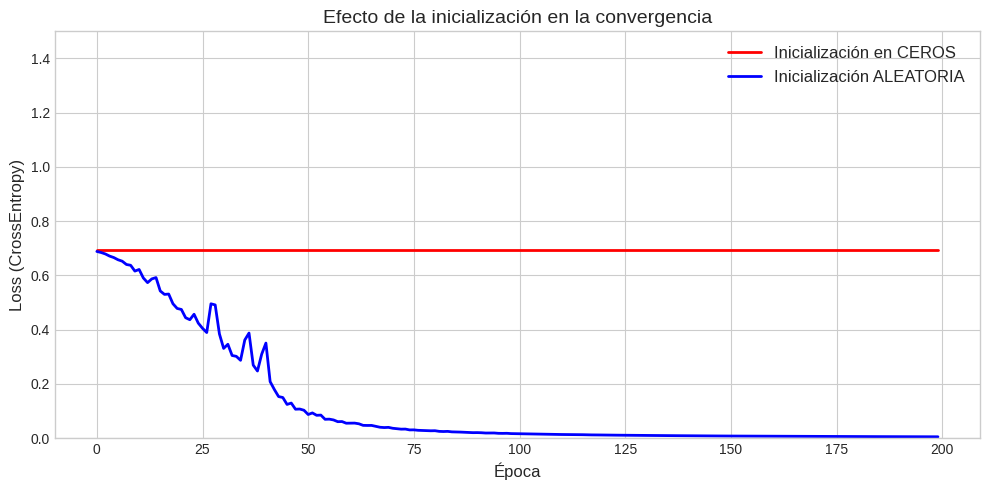

In [ ]:
# --- Gráfico comparativo ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses_zeros, label="Inicialización en CEROS", linewidth=2, color="red")
ax.plot(losses_random, label="Inicialización ALEATORIA", linewidth=2, color="blue")
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("Loss (CrossEntropy)", fontsize=12)
ax.set_title("Efecto de la inicialización en la convergencia", fontsize=14)
ax.legend(fontsize=12)
ax.set_ylim(0, 1.5)
plt.tight_layout()
plt.show()

### ¿Por qué la inicialización en ceros falla? — Ruptura de Simetría

Cuando **todos los pesos son idénticos** (en particular, todos cero), ocurre lo siguiente:

1. **Forward pass**: Ambas neuronas ocultas reciben exactamente la misma entrada y producen exactamente la misma salida (ambas son 0 en este caso).

2. **Backward pass**: Como ambas neuronas produjeron la misma salida, ambas reciben exactamente el **mismo gradiente**.

3. **Actualización**: Como tenían los mismos pesos Y recibieron los mismos gradientes, ambas se actualizan de forma **idéntica**.

4. **Resultado**: Las dos neuronas ocultas **nunca se diferencian** entre sí. Son clones perpetuos. Es como tener una sola neurona oculta, lo cual es insuficiente para resolver XOR.

Esto se conoce como el **problema de simetría**. La inicialización aleatoria **rompe esta simetría**:
cada neurona arranca en un punto diferente del espacio de pesos, recibe gradientes ligeramente
diferentes, y evoluciona hacia funciones distintas.

> **Lección clave**: Nunca inicialices todos los pesos de una red neuronal en el mismo valor.
> La inicialización aleatoria es esencial para que las neuronas aprendan representaciones diversas.

In [ ]:
# Verifiquemos: ¿las neuronas ocultas se quedaron iguales?
print("--- Pesos de la capa oculta después del entrenamiento (init ceros) ---")
for i in range(model_zeros.hidden.weight.shape[0]):
    print(f"  Neurona {i}: W = {model_zeros.hidden.weight.data[i].tolist()}, b = {model_zeros.hidden.bias.data[i].item():.4f}")
print()

print("--- Pesos de la capa oculta después del entrenamiento (init aleatoria) ---")
for i in range(model_random.hidden.weight.shape[0]):
    print(f"  Neurona {i}: W = {model_random.hidden.weight.data[i].tolist()}, b = {model_random.hidden.bias.data[i].item():.4f}")
print()
print("→ Con init en ceros, TODAS las neuronas son IDÉNTICAS (simetría no rota).")
print("→ Con init aleatoria, cada neurona aprendió una función DIFERENTE.")

--- Pesos de la capa oculta después del entrenamiento (init ceros) ---
  Neurona 0: W = [0.0, 0.0], b = 0.0000
  Neurona 1: W = [0.0, 0.0], b = 0.0000
  Neurona 2: W = [0.0, 0.0], b = 0.0000
  Neurona 3: W = [0.0, 0.0], b = 0.0000

--- Pesos de la capa oculta después del entrenamiento (init aleatoria) ---
  Neurona 0: W = [1.144534707069397, 0.1829400658607483], b = 0.7399
  Neurona 1: W = [-1.5150898694992065, 1.512005090713501], b = -0.0033
  Neurona 2: W = [-1.8469374179840088, 2.382115602493286], b = 1.8568
  Neurona 3: W = [-3.075502872467041, 3.0663623809814453], b = -0.0076

→ Con init en ceros, TODAS las neuronas son IDÉNTICAS (simetría no rota).
→ Con init aleatoria, cada neurona aprendió una función DIFERENTE.


---
## 5) Experimento 2: BCE vs CrossEntropy — Dos Formas de Clasificar

En clasificación binaria hay **dos formas válidas** de diseñar la salida de la red:

| Aspecto | Versión 1: BCE | Versión 2: CrossEntropy |
|---------|---------------|------------------------|
| Neuronas de salida | **1** | **2** (una por clase) |
| Activación final | **Sigmoid** (→ probabilidad) | **Ninguna** (logits crudos) |
| Función de pérdida | `BCELoss` o `BCEWithLogitsLoss` | `CrossEntropyLoss` |
| Formato de etiquetas | Float: `[0., 1., 1., 0.]` | Long: `[0, 1, 1, 0]` |
| Predicción | `p > 0.5 → clase 1` | `argmax(logits)` |

Ambas resuelven el mismo problema. Veamos cada una en acción.

### Versión 1: Una Salida con BCE (Binary Cross-Entropy)

Aquí la red tiene **1 neurona de salida** que produce un número entre 0 y 1 (gracias a Sigmoid).

Ese número se interpreta como $P(\text{clase}=1)$.

**Nota sobre `BCELoss` vs `BCEWithLogitsLoss`:**
- `BCELoss` espera probabilidades (ya pasadas por Sigmoid). Tú aplicas Sigmoid manualmente.
- `BCEWithLogitsLoss` aplica Sigmoid internamente + calcula BCE en un solo paso. Es **numéricamente más estable** porque usa el truco del log-sum-exp.

Usaremos `BCEWithLogitsLoss` (la versión recomendada) y dejaremos la salida como logit crudo.

In [ ]:
class ToyMLP_BCE(nn.Module):
    """
    MLP con 1 sola neurona de salida para clasificación binaria con BCE.
    """
    def __init__(self, hidden_size=4):
        super().__init__()
        self.hidden = nn.Linear(2, hidden_size)
        self.output = nn.Linear(hidden_size, 1)  # ← UNA sola neurona de salida

    def forward(self, x):
        h = F.relu(self.hidden(x))
        # Retornamos el logit CRUDO (sin sigmoid).
        # BCEWithLogitsLoss aplicará sigmoid internamente.
        logit = self.output(h)  # forma: (batch, 1)
        return logit.squeeze(-1)  # forma: (batch,) para que coincida con y

In [ ]:
def train_model_bce(model, X, y_float, epochs=200, lr=1.0, verbose=True):
    """
    Entrenamiento con BCEWithLogitsLoss (1 salida).
    y_float debe ser FloatTensor con valores 0.0 o 1.0.
    """
    # BCEWithLogitsLoss = Sigmoid + BCELoss (en un paso numéricamente estable)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):
        logits = model(X)                   # Forward: logits crudos (4,)
        loss = criterion(logits, y_float)    # BCE sobre logits

        optimizer.zero_grad()                # Limpiar gradientes
        loss.backward()                      # Calcular gradientes
        optimizer.step()                     # ACTUALIZAR PESOS

        losses.append(loss.item())

        if verbose and (epoch % 50 == 0 or epoch == epochs - 1):
            with torch.no_grad():
                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).long()
                acc = (preds == y_float.long()).float().mean().item()
            print(f"Época {epoch:4d} | Loss: {loss.item():.4f} | Acc: {acc:.0%} | Probs: {probs.detach().tolist()}")

    return losses

In [ ]:
# Etiquetas como float para BCE
y_float = y.float()  # [0., 1., 1., 0.]

torch.manual_seed(42)
model_bce = ToyMLP_BCE(hidden_size=4)

print("=== Versión 1: Entrenamiento con BCEWithLogitsLoss (1 salida) ===")
losses_bce = train_model_bce(model_bce, X, y_float, epochs=200, lr=1.0)

=== Versión 1: Entrenamiento con BCEWithLogitsLoss (1 salida) ===
Época    0 | Loss: 0.8065 | Acc: 50% | Probs: [0.6801685690879822, 0.7281572818756104, 0.7163119316101074, 0.7618938088417053]
Época   50 | Loss: 0.3577 | Acc: 100% | Probs: [0.3121466636657715, 0.9077772498130798, 0.5210855007171631, 0.26519909501075745]
Época  100 | Loss: 0.0467 | Acc: 100% | Probs: [0.047161586582660675, 0.9806234240531921, 0.929404616355896, 0.044641055166721344]
Época  150 | Loss: 0.0167 | Acc: 100% | Probs: [0.01656949333846569, 0.9910507202148438, 0.9747726917266846, 0.015424334444105625]
Época  199 | Loss: 0.0094 | Acc: 100% | Probs: [0.009388438425958157, 0.9946551322937012, 0.9857501983642578, 0.008424202911555767]


### Versión 2: Dos Salidas con CrossEntropyLoss

Aquí la red tiene **2 neuronas de salida**: una para la clase 0, otra para la clase 1.

La red produce **logits crudos** (sin activación). `CrossEntropyLoss` aplica internamente
Softmax + NLLLoss.

Esta es la misma arquitectura que usamos en la Sección 2. La repetimos aquí para la comparación directa.

In [ ]:
torch.manual_seed(42)
model_ce = ToyMLP(hidden_size=4, output_size=2)  # 2 salidas

print("=== Versión 2: Entrenamiento con CrossEntropyLoss (2 salidas) ===")
losses_ce = train_model(model_ce, X, y, epochs=200, lr=1.0)

=== Versión 2: Entrenamiento con CrossEntropyLoss (2 salidas) ===
Época    0 | Loss: 0.6882 | Acc: 50% | Preds: [0, 0, 0, 0]
Época   50 | Loss: 0.0869 | Acc: 100% | Preds: [0, 1, 1, 0]
Época  100 | Loss: 0.0162 | Acc: 100% | Preds: [0, 1, 1, 0]
Época  150 | Loss: 0.0076 | Acc: 100% | Preds: [0, 1, 1, 0]
Época  199 | Loss: 0.0048 | Acc: 100% | Preds: [0, 1, 1, 0]


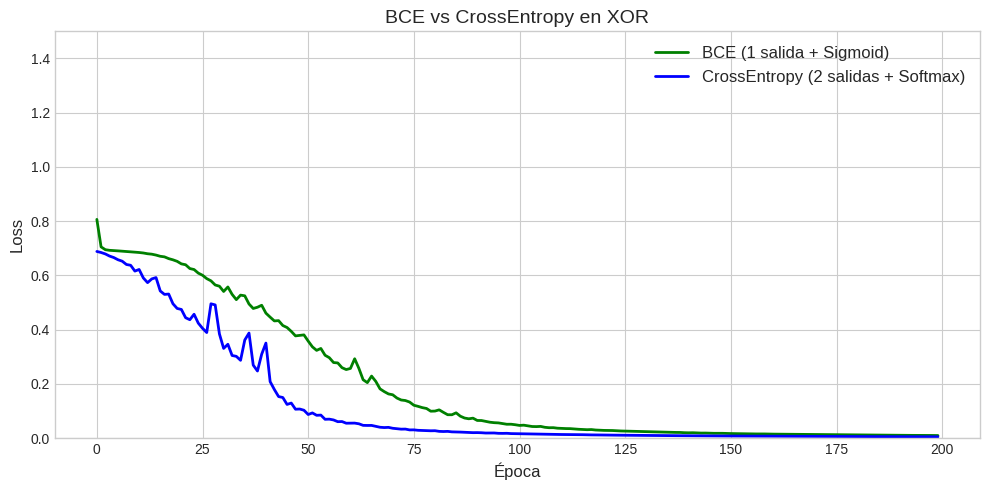

In [ ]:
# --- Gráfico comparativo BCE vs CE ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses_bce, label="BCE (1 salida + Sigmoid)", linewidth=2, color="green")
ax.plot(losses_ce, label="CrossEntropy (2 salidas + Softmax)", linewidth=2, color="blue")
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("BCE vs CrossEntropy en XOR", fontsize=14)
ax.legend(fontsize=12)
ax.set_ylim(0, 1.5)
plt.tight_layout()
plt.show()

In [ ]:
# --- Verificar resultados de ambos modelos ---
print("=" * 55)
print("RESULTADOS FINALES")
print("=" * 55)

# Modelo BCE
with torch.no_grad():
    logits_bce = model_bce(X)
    probs_bce = torch.sigmoid(logits_bce)
    preds_bce = (probs_bce > 0.5).long()

print("\n--- Modelo BCE (1 salida) ---")
print(f"{'X1':>3} {'X2':>3} | {'y_real':>6} | {'y_pred':>6} | {'P(clase=1)':>10}")
print("-" * 45)
for i in range(4):
    print(f"{X[i,0].item():3.0f} {X[i,1].item():3.0f} | {y[i].item():6d} | {preds_bce[i].item():6d} | {probs_bce[i].item():10.4f}")

# Modelo CE
with torch.no_grad():
    logits_ce = model_ce(X)
    probs_ce = F.softmax(logits_ce, dim=1)
    preds_ce = logits_ce.argmax(dim=1)

print("\n--- Modelo CrossEntropy (2 salidas) ---")
print(f"{'X1':>3} {'X2':>3} | {'y_real':>6} | {'y_pred':>6} | {'P(clase0)':>9} {'P(clase1)':>9}")
print("-" * 55)
for i in range(4):
    print(f"{X[i,0].item():3.0f} {X[i,1].item():3.0f} | {y[i].item():6d} | {preds_ce[i].item():6d} | {probs_ce[i,0].item():9.4f} {probs_ce[i,1].item():9.4f}")

RESULTADOS FINALES

--- Modelo BCE (1 salida) ---
 X1  X2 | y_real | y_pred | P(clase=1)
---------------------------------------------
  0   0 |      0 |      0 |     0.0093
  0   1 |      1 |      1 |     0.9940
  1   0 |      1 |      1 |     0.9859
  1   1 |      0 |      0 |     0.0082

--- Modelo CrossEntropy (2 salidas) ---
 X1  X2 | y_real | y_pred | P(clase0) P(clase1)
-------------------------------------------------------
  0   0 |      0 |      0 |    0.9954    0.0046
  0   1 |      1 |      1 |    0.0031    0.9969
  1   0 |      1 |      1 |    0.0075    0.9925
  1   1 |      0 |      0 |    0.9960    0.0040


### Relación entre BCE y CrossEntropy

Ambas formulaciones son **matemáticamente equivalentes** para clasificación binaria:

| | BCE (1 salida) | CrossEntropy (2 salidas) |
|---|---|---|
| La red produce | 1 logit $z$ | 2 logits $[z_0, z_1]$ |
| Se convierte a probabilidad con | $\sigma(z) = \frac{1}{1+e^{-z}}$ (Sigmoid) | $\text{softmax}([z_0, z_1])$ |
| La pérdida mide | $-[y\log(p) + (1-y)\log(1-p)]$ | $-\log\frac{e^{z_y}}{\sum_j e^{z_j}}$ |

De hecho, Sigmoid es un **caso particular** de Softmax con 2 clases.
Si fijamos $z_0 = 0$ y dejamos $z_1 = z$, entonces $\text{softmax}_1 = \sigma(z)$.

**¿Cuándo usar cada una?**

- **BCE (1 salida)**: Es suficiente para problemas estrictamente binarios. Más eficiente en memoria.
- **CrossEntropy (2+ salidas)**: Es la formulación **general**. Funciona para 2, 10, 100 o cualquier número de clases. Por eso es el estándar en PyTorch.

> **Conclusión**: La versión de 2 salidas con CrossEntropy es la base para problemas **multiclase**.
> Al cambiar `output_size=2` por `output_size=10`, pasamos de XOR a clasificar dígitos MNIST.
> La estructura del código es **exactamente la misma**.

---
## 6) Resumen

### Lo que aprendimos hoy:

1. **El ciclo de entrenamiento** tiene 5 pasos: forward → loss → `zero_grad()` → `backward()` → `step()`.
   - `backward()` *calcula* los gradientes.
   - `step()` *actualiza* los pesos. **Sin `step()`, la red no aprende.**

2. **Inicialización importa**: Si todos los pesos arrancan iguales, las neuronas ocultas nunca se diferencian (problema de simetría). La inicialización aleatoria **rompe la simetría** y permite que cada neurona aprenda algo distinto.

3. **BCE vs CrossEntropy**:
   - BCE usa 1 salida + Sigmoid → para problemas binarios.
   - CrossEntropy usa N salidas + Softmax → para problemas de N clases.
   - Para 2 clases, ambas son equivalentes. CrossEntropy es la formulación general.

4. **XOR no es linealmente separable**: necesita al menos 1 capa oculta con activación no lineal. Es el ejemplo mínimo que demuestra la necesidad de redes profundas.

In [ ]:
# Verificación rápida
with torch.no_grad():
    a1 = (model_random(X).argmax(1)==y).float().mean().item()
    a2 = (model_zeros(X).argmax(1)==y).float().mean().item()
    a3 = ((torch.sigmoid(model_bce(X))>0.5).long()==y).float().mean().item()
    a4 = (model_ce(X).argmax(1)==y).float().mean().item()
print(f"Random CE: {a1:.0%} | Zeros CE: {a2:.0%} | BCE: {a3:.0%} | CE exp2: {a4:.0%}")
print(f"Loss final: random={losses_random[-1]:.4f} zeros={losses_zeros[-1]:.4f} bce={losses_bce[-1]:.4f} ce={losses_ce[-1]:.4f}")

Random CE: 100% | Zeros CE: 50% | BCE: 100% | CE exp2: 100%
Loss final: random=0.0048 zeros=0.6931 bce=0.0094 ce=0.0048
